# Exploratory Data Analisys

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [87]:
path = 'dados/dadosLimpos.parquet'

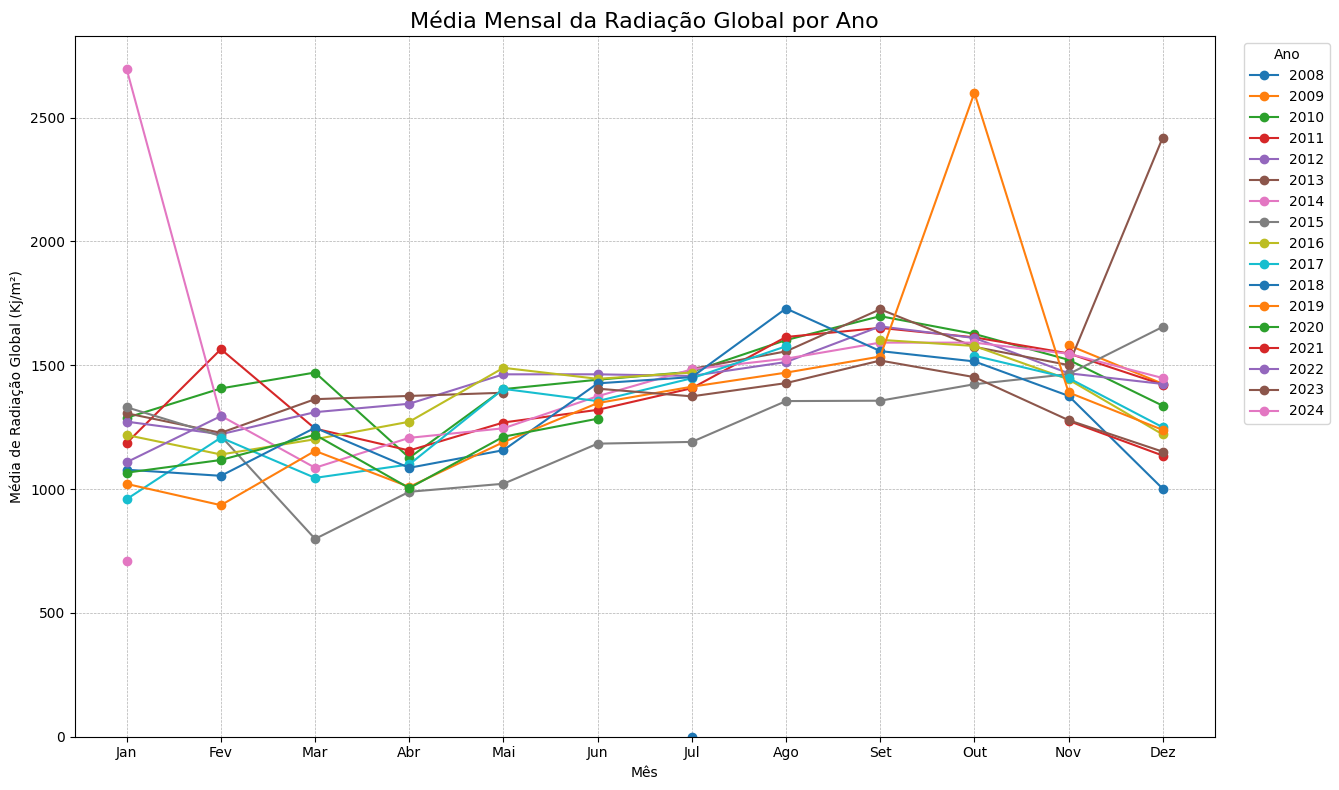

In [66]:
# --- 2. Preparação dos Dados para o Gráfico ---
# Extrai o ano e o mês do índice de data e hora para novas colunas.
df['year'] = df.index.year
df['month'] = df.index.month

# Agrupa os dados por ano e mês para calcular a média de radiação.
# O método .unstack() pivota os anos, transformando-os em colunas,
# o que é o formato ideal para plotagem.
monthly_avg = df.groupby(['year', 'month'])['GLOBAL RADIATION (Kj/m²)'].mean().unstack(level='year')


# --- 3. Geração do Gráfico ---
# Cria a figura e os eixos para o gráfico com um tamanho definido.
fig, ax = plt.subplots(figsize=(15, 8))

# Plota os dados da tabela 'monthly_avg'. O pandas plota cada coluna (ano) como uma linha separada.
monthly_avg.plot(ax=ax, marker='o', linestyle='-')

# --- 4. Customização e Melhorias Visuais ---
# Define o título e os rótulos dos eixos.
ax.set_title('Média Mensal da Radiação Global por Ano', fontsize=16)
ax.set_xlabel('Mês')
ax.set_ylabel('Média de Radiação Global (Kj/m²)')

# Formata o eixo X para mostrar os nomes dos meses em vez de números (1-12).
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Garante que o eixo Y comece em zero para uma melhor perspectiva.
ax.set_ylim(bottom=0)

# Adiciona e posiciona a legenda do lado de fora do gráfico para não obstruir os dados.
ax.legend(title='Ano', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adiciona uma grade para facilitar a leitura dos valores.
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Ajusta o layout para garantir que a legenda não seja cortada.
plt.tight_layout(rect=[0, 0, 0.9, 1])

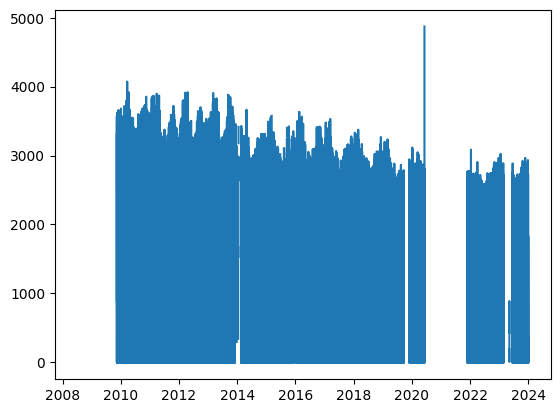

In [ ]:
plt.plot(df['GLOBAL RADIATION (Kj/m²)'])

### Funções, 1 - Processar os dados

In [88]:
def preprocessar_dados(dados):
    path = dados
    dados = pd.read_parquet(path)
    #dados.set_index('Data_Hora', inplace = True)
   # df.sort_index(inplace=True)
    dados.dropna(inplace =True)
    dados = dados[(dados.index.hour >= 6) & (dados.index.hour <=18)]
    colunas_araujo = ['WIND, HOURLY SPEED (m/s)',
              'AIR RELATIVE HUMIDITY, HOURLY (%)',
              'DEW POINT TEMPERATURE (°C)',
              'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
              'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)']

    y = dados['GLOBAL RADIATION (Kj/m²)']
    X = dados[colunas_araujo]

    size = 0.7
    train_size = int(len(y)*size)

    X_treino, X_teste = X[:train_size], X[train_size:]
    y_treino, y_teste = y[:train_size], y[train_size:]

    val_size = 0.5
    val = int(len(y_teste) * val_size)
    x_val, y_val = X_teste.iloc[val:], y_teste.iloc[val:]

    print(f'Dados carregados, limpos e divididos! /n dados treino {X_treino.shape} dados teste {X_teste.shape}')
    return X_treino, X_teste, y_treino, y_teste, x_val, y_val, dados 
def remove_outliers(df): 
    outliers_by_hour = {}
    df['hour'] = df.index.hour
    for hour in range(24):
        hour_data = df[df['hour'] == hour]['GLOBAL RADIATION (Kj/m²)']
        Q1 = hour_data.quantile(0.25)
        Q3 = hour_data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = hour_data[(hour_data < lower) | (hour_data > upper)]
        outliers_by_hour[hour] = outliers
        df = df[~df.index.isin(outliers.index)]
    return df
        

In [89]:
X_treino, X_teste, y_train, y_test, _, __, df = preprocessar_dados(path) 

Dados carregados, limpos e divididos! /n dados treino (33612, 5) dados teste (14406, 5)


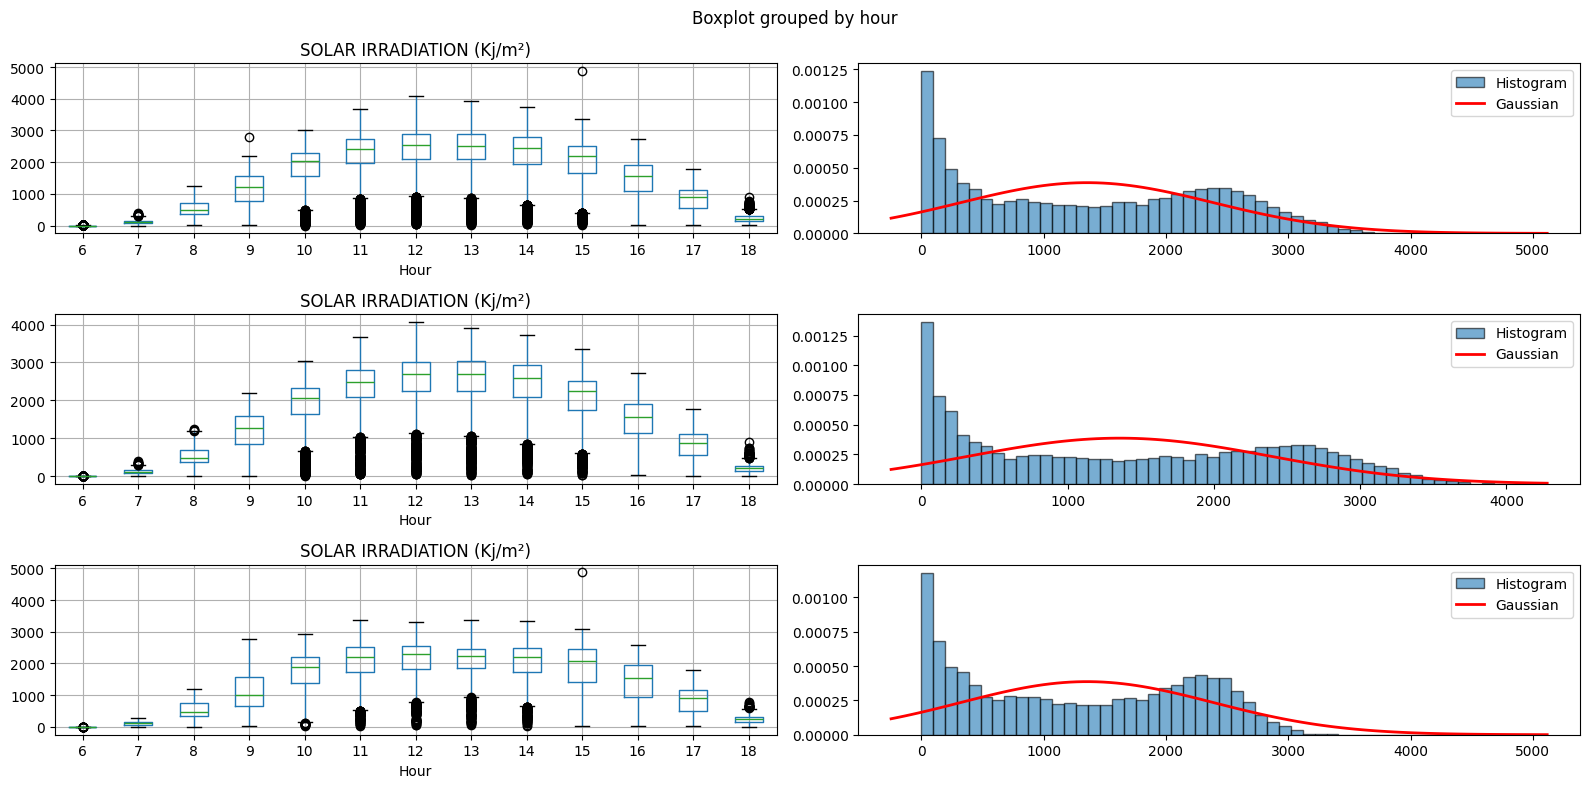

In [90]:
fig, ax = plt.subplots(3,2,figsize=(16,8))
all_data = df
#all_data.rename(columns={'index': 'Data_Hora'}, inplace=True)
all_data['hour'] = all_data.index.hour
all_data.boxplot(column='GLOBAL RADIATION (Kj/m²)', by= 'hour', ax=ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(all_data['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[0,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()


tempdf = y_train.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf['Data_Hora'].dt.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdf['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()


tempdftest = y_test.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = tempdftest['Data_Hora'].dt.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[2,0])
ax[2,0].set_xlabel('Hour')
ax[2,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[2,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[2,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[2,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[2,1].legend()
plt.tight_layout()
plt.show()

### remoção de Outliers

In [91]:
df = remove_outliers(df)

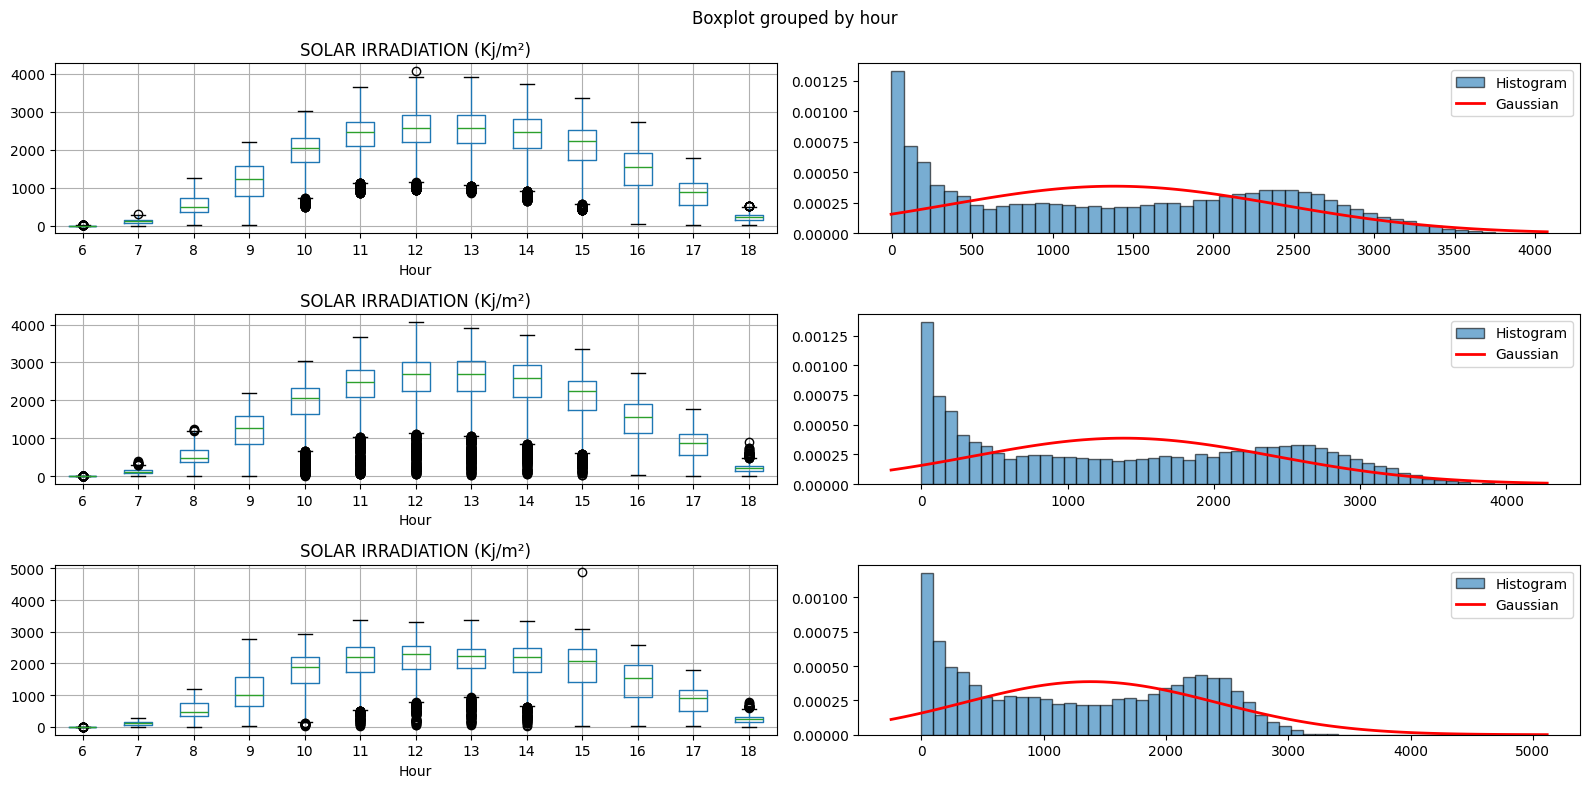

In [92]:

fig, ax = plt.subplots(3,2,figsize=(16,8))
all_data = df
#all_data.rename(columns={'index': 'Data_Hora'}, inplace=True)
all_data['hour'] = all_data.index.hour
all_data.boxplot(column='GLOBAL RADIATION (Kj/m²)', by= 'hour', ax=ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(all_data['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax = df['GLOBAL RADIATION (Kj/m²)'].min(), df['GLOBAL RADIATION (Kj/m²)'].max()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()


tempdf = y_train.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf['Data_Hora'].dt.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdf['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()


tempdftest = y_test.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = tempdftest['Data_Hora'].dt.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[2,0])
ax[2,0].set_xlabel('Hour')
ax[2,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[2,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[2,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[2,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[2,1].legend()
plt.tight_layout()
plt.show()

In [125]:
dados_manha = df[(df.index.hour < 11)]
dados_meio_dia = df[(df.index.hour > 10)& (df.index.hour < 15)]
dados_tarde = df[(df.index.hour > 14) & (df.index.hour < 19)]
dados_manha = pd.DataFrame(dados_manha)
dados_meio_dia = pd.DataFrame(dados_meio_dia)
dados_tarde = pd.DataFrame(dados_tarde)


dados_periodo_do_dia = [dados_manha, 
                        dados_meio_dia,
                        dados_tarde]

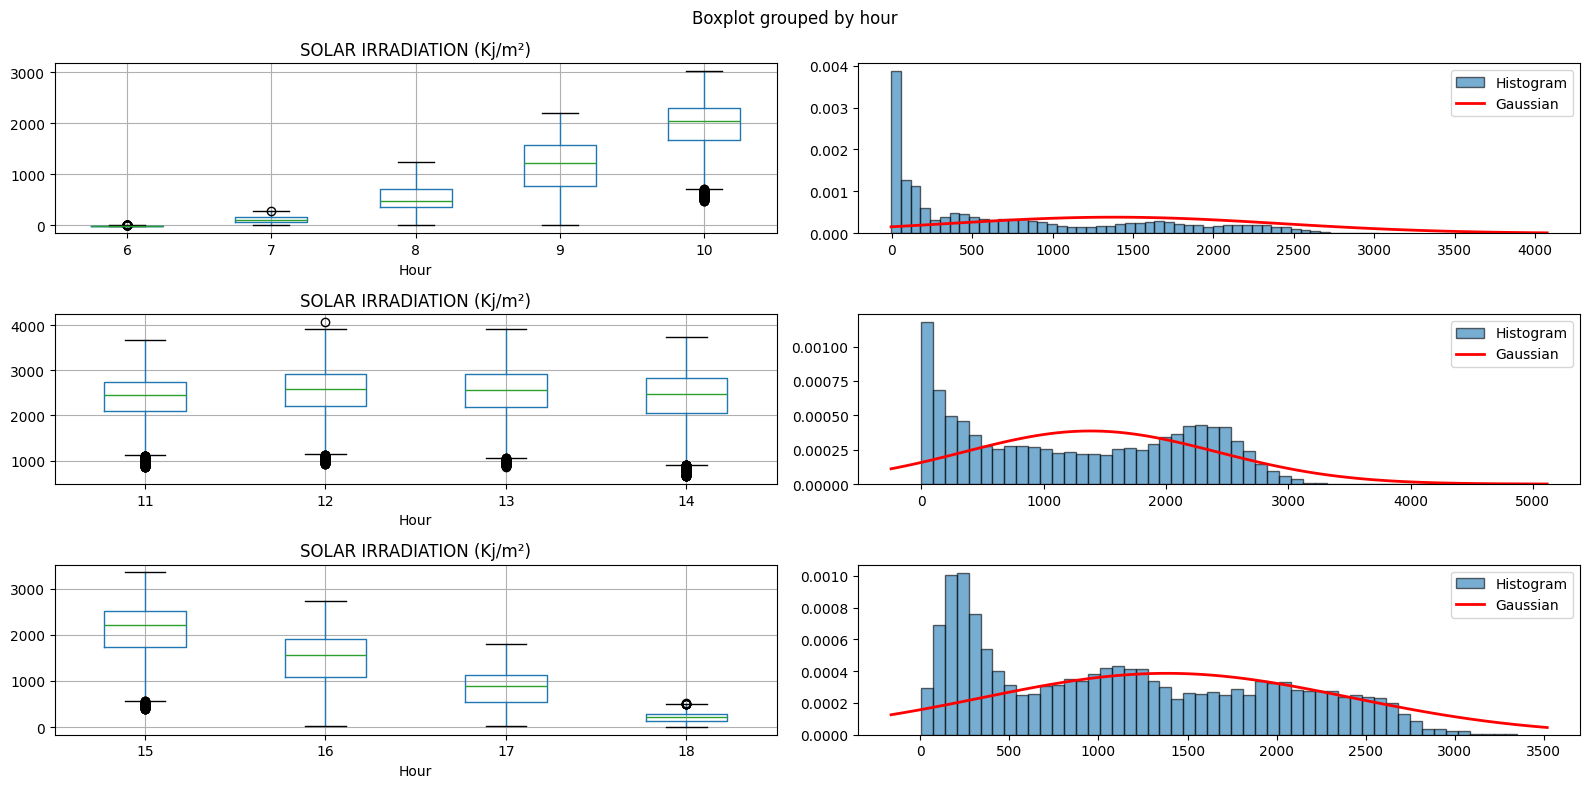

In [133]:

fig, ax = plt.subplots(3,2,figsize=(16,8))
all_data = dados_manha
all_data.rename(columns={'index': 'Data_Hora'}, inplace=True)
all_data['hour'] = dados_manha.index.hour
all_data.boxplot(column='GLOBAL RADIATION (Kj/m²)', by= 'hour', ax=ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(all_data['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax = df['GLOBAL RADIATION (Kj/m²)'].min(), df['GLOBAL RADIATION (Kj/m²)'].max()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()


tempdf = dados_meio_dia
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf.index.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()


tempdftest = dados_tarde
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = dados_tarde.index.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[2,0])
ax[2,0].set_xlabel('Hour')
ax[2,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[2,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[2,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[2,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[2,1].legend()
plt.tight_layout()
plt.show()